# Predictors of Winning in Toxic Multi-Agent Debates (LLaMA)

In [1]:
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from src.extract_starting_agent import get_agent_who_starts

In [2]:
df_llama = pd.read_csv("../data/evaluation/convergence_of_691_toxic_random_discussions_llama.csv", sep =",")

In [3]:
dt_llama = df_llama[df_llama["reason_for_convergence"] != "moderator detected alignment"]
dt_llama.groupby("which_agent_is_toxic")["reason_for_convergence"].value_counts(normalize=True)

which_agent_is_toxic     reason_for_convergence
con has toxic behaviour  pro has been convinced    0.603093
                         con has been convinced    0.396907
pro has toxic behaviour  con has been convinced    0.611607
                         pro has been convinced    0.388393
Name: proportion, dtype: float64

In [4]:
dt_llama = dt_llama.copy()
dt_llama["toxic_agent"] = dt_llama.apply(lambda row: 0 if row["which_agent_is_toxic"] == "pro has toxic behaviour" else 1 , axis=1) # 0 for pro is toxic, 1 for con is toxic

### One-Sample T-Test
The toxic Agent for CON is winning significantly more than 50% of the time.

In [5]:
# PRO
pro_toxic = (dt_llama[dt_llama["toxic_agent"] == 0]["reason_for_convergence"] == "con has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(pro_toxic, popmean=0.5)
print(f"PRO toxic:")
print(f"  win rate: {pro_toxic.mean():.4f}")
print(f"  p-value: {p_value:.4f}")

# CON
con_toxic = (dt_llama[dt_llama["toxic_agent"] == 1]["reason_for_convergence"] == "pro has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(con_toxic, popmean=0.5)
print(f"CON toxic:")
print(f"  win rate: {con_toxic.mean():.4f}")
print(f"  p-value: {p_value:.4f}")

PRO toxic:
  win rate: 0.6116
  p-value: 0.0007
CON toxic:
  win rate: 0.6031
  p-value: 0.0038


### Two-Sample T-Test
Both PRO and CON toxic agents are winning significantly more than their non-toxic counterparts. The winning-rate for the CON toxic agent is higher that the PRO toxic agent.

In [6]:
# PRO
# when pro is toxic (toxic_agent == 0), pro wins = con gets convinced
pro_toxic_wins = (dt_llama[dt_llama["toxic_agent"] == 0]["reason_for_convergence"] == "con has been convinced").astype(int)

# when con is toxic (toxic_agent == 1), pro is NOT toxic -> pro wins = con gets convinced
pro_nontoxic_wins = (dt_llama[dt_llama["toxic_agent"] == 1]["reason_for_convergence"] == "con has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(pro_toxic_wins, pro_nontoxic_wins)
print(f"PRO toxic win rate: {pro_toxic_wins.mean():.4f}")
print(f"PRO non-toxic win rate: {pro_nontoxic_wins.mean():.4f}")
print(f"p-value: {p_value:.4f}")

# CON
con_toxic_wins = (dt_llama[dt_llama["toxic_agent"] == 1]["reason_for_convergence"] == "pro has been convinced").astype(int)
con_nontoxic_wins = (dt_llama[dt_llama["toxic_agent"] == 0]["reason_for_convergence"] == "pro has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(con_toxic_wins, con_nontoxic_wins)
print(f"CON toxic win rate: {con_toxic_wins.mean():.4f}")
print(f"CON non-toxic win rate: {con_nontoxic_wins.mean():.4f}")
print(f"p-value: {p_value:.4f}")

PRO toxic win rate: 0.6116
PRO non-toxic win rate: 0.3969
p-value: 0.0000
CON toxic win rate: 0.6031
CON non-toxic win rate: 0.3884
p-value: 0.0000


### AVOVA
Toxicity level has no effect on the winning rate of the Toxic Agent

In [7]:
dt_llama = dt_llama.copy()
dt_llama["pro_wins"] = (dt_llama["reason_for_convergence"] == "con has been convinced").astype(int)
dt_llama["con_wins"] = (dt_llama["reason_for_convergence"] == "pro has been convinced").astype(int)

In [8]:
groups_pro = [group["pro_wins"].values for _, group in dt_llama.groupby("toxicity_level")]
f_stat, p_value = stats.f_oneway(*groups_pro)
print(f"PRO wins by toxicity:")
print(f"  F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print(dt_llama.groupby("toxicity_level")["pro_wins"].mean())

PRO wins by toxicity:
  F-statistic: 0.2803, P-value: 0.7557
toxicity_level
mild        0.492537
moderate    0.506667
no          0.537313
Name: pro_wins, dtype: float64


In [9]:
groups_con = [group["con_wins"].values for _, group in dt_llama.groupby("toxicity_level")]
f_stat, p_value = stats.f_oneway(*groups_con)
print(f"CON wins by toxicity:")
print(f"  F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
print(dt_llama.groupby("toxicity_level")["con_wins"].mean())

CON wins by toxicity:
  F-statistic: 0.2803, P-value: 0.7557
toxicity_level
mild        0.507463
moderate    0.493333
no          0.462687
Name: con_wins, dtype: float64


# Toxic behaviour significantly increases the Win Rate

In [10]:
directory = Path('../data/toxic_and_baseline_random_llama')
dt_llama["starting_agent"] = dt_llama["Path"].apply(get_agent_who_starts(directory))

In [11]:
dt_llama.groupby("starting_agent")["reason_for_convergence"].value_counts(normalize=True)

starting_agent  reason_for_convergence
con             pro has been convinced    0.676617
                con has been convinced    0.323383
pro             con has been convinced    0.686636
                pro has been convinced    0.313364
Name: proportion, dtype: float64

In [12]:
dt_llama["starting_agent"].value_counts(normalize=True)

starting_agent
pro    0.519139
con    0.480861
Name: proportion, dtype: float64

### Two-Sample T-Test
The Agent who starts the discussion does win with a significant higher Chance.


In [13]:
con_winning = (dt_llama[dt_llama["starting_agent"] == "con"]["reason_for_convergence"] == "pro has been convinced").astype(int)
con_loosing = (dt_llama[dt_llama["starting_agent"] == "con"]["reason_for_convergence"] == "con has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(con_winning, con_loosing)
print(f"CON t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

pro_winning = (dt_llama[dt_llama["starting_agent"] == "pro"]["reason_for_convergence"] == "con has been convinced").astype(int)
pro_loosing = (dt_llama[dt_llama["starting_agent"] == "pro"]["reason_for_convergence"] == "pro has been convinced").astype(int)

t_stat, p_value = stats.ttest_ind(pro_winning, pro_loosing)
print(f"PRO t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

CON t-statistic: 7.5515
p-value: 0.0000
PRO t-statistic: 8.3628
p-value: 0.0000


### One-Sample T-Test
Starting Agent is winning significantly more than 50% of the time (Equally for PRO and CON)

In [14]:
# when con starts, do they win more than 50%?
con_outcomes = (dt_llama[dt_llama["starting_agent"] == "con"]["reason_for_convergence"] == "pro has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(con_outcomes, popmean=0.5)
print(f"CON starter:")
print(f"  win rate: {con_outcomes.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

# when pro starts, do they win more than 50%?
pro_outcomes = (dt_llama[dt_llama["starting_agent"] == "pro"]["reason_for_convergence"] == "con has been convinced").astype(int)
t_stat, p_value = stats.ttest_1samp(pro_outcomes, popmean=0.5)
print(f"PRO starter:")
print(f"  win rate: {pro_outcomes.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")

CON starter:
  win rate: 0.6766
  t-statistic: 5.3397
  p-value: 0.0000
PRO starter:
  win rate: 0.6866
  t-statistic: 5.9134
  p-value: 0.0000


### ANOVA
The winning rate of the starter of the discussion is independent of the toxicity level of the toxic agent.

In [15]:
dt_llama["starter_wins"] = (
        ((dt_llama["starting_agent"] == "con") & (dt_llama["reason_for_convergence"] == "pro has been convinced")) |
        ((dt_llama["starting_agent"] == "pro") & (dt_llama["reason_for_convergence"] == "con has been convinced"))
).astype(int)
dt_llama.groupby("toxicity_level")["starter_wins"].mean()

toxicity_level
mild        0.641791
moderate    0.660000
no          0.746269
Name: starter_wins, dtype: float64

In [16]:
dt_llama["winning_agent"] = dt_llama.apply(lambda row: 0 if row["reason_for_convergence"] == "pro has been convinced" else 1 , axis=1) # 0 for pro wins, 1 for con wins

In [17]:
groups = [group["starter_wins"].values for _, group in dt_llama.groupby("toxicity_level")]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# group means for overview
print(dt_llama.groupby("toxicity_level")["starter_wins"].mean())

F-statistic: 1.9464
P-value: 0.1441
toxicity_level
mild        0.641791
moderate    0.660000
no          0.746269
Name: starter_wins, dtype: float64


# Maximal number of rounds per discussion increase with toxicity level

In [18]:
df_llama = df_llama.copy()
df_llama.groupby("toxicity_level")["max_round_per_discussion"].agg(["mean", "var", "size"])

,mean,var,size
toxicity_level,,,
mild,4.622807,4.685293,228
moderate,8.476190,89.459213,231
no,3.405172,4.588371,232


In [19]:
groups = [group["max_round_per_discussion"].values for _, group in df_llama.groupby("toxicity_level")]

f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# group means for overview
print(df_llama.groupby("toxicity_level")["max_round_per_discussion"].mean())

F-statistic: 49.0963
P-value: 0.0000
toxicity_level
mild        4.622807
moderate    8.476190
no          3.405172
Name: max_round_per_discussion, dtype: float64


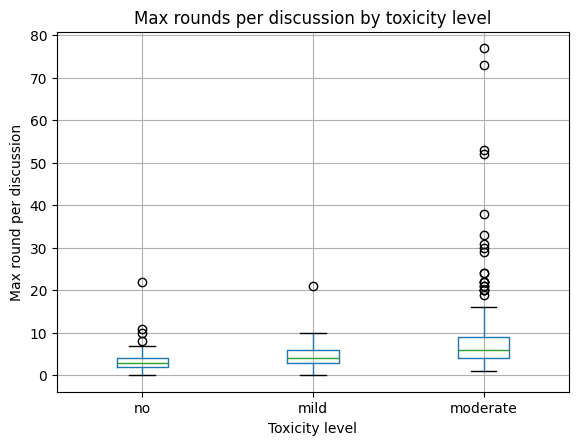

In [20]:
order = ["no", "mild", "moderate"]
df_llama["toxicity_level"] = pd.Categorical(df_llama["toxicity_level"], categories=order, ordered=True)

df_llama.boxplot(column="max_round_per_discussion", by="toxicity_level")
plt.title("Max rounds per discussion by toxicity level")
plt.xlabel("Toxicity level")
plt.ylabel("Max round per discussion")
plt.suptitle("")
plt.show()